# Модель 1: Сегментация клиентов санатория

**Цель:** сегментировать гостей санатория на осмысленные кластеры для управления загрузкой номерного фонда.

**Данные:** `silver.csv` — 565 816 строк, 24 колонки. Используем строки с `is_valid_for_rfm == 1` (известные гости).

**Выход:** `df_for_model_claster` — 436 492 гостя × 12 признаков, готово для `ColumnTransformer → KMeans`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

In [2]:
silver = pd.read_csv('silver.csv')
df = silver.copy()

## 0. Загрузка данных и первичный осмотр

In [3]:
df.head()

,Unnamed: 0,created_dt,check_in_dt,check_out_dt,activity_dt,is_valid_for_rfm,tariff,discount,composition,grp,...,guest_last_name,citizenship,gender,guest_age,prev_stays,rooms,places,extra_places,children,adults
0,0,2020-12-01,2021-01-30 14:00:00,2021-02-01 12:00:00,2021-02-01 12:00:00,0,Все Включено 2021,25.0,NaN,923 160,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,1,2020-12-01,2020-12-15 14:00:00,2020-12-22 12:00:00,2020-12-22 12:00:00,1,Открытый Юг/Доступный Юг от 7 суток 2020г.,NaN,NaN,923 196,...,Санкин,РОССИЯ,Мужской,61.0,1.0,NaN,1.0,NaN,NaN,NaN
2,2,2020-12-01,2021-01-30 14:00:00,2021-02-04 12:00:00,2021-02-04 12:00:00,0,Все Включено 2021,25.0,NaN,923 143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3,3,2020-12-01,2021-02-19 14:00:00,2021-02-23 12:00:00,2021-02-23 12:00:00,1,Все Включено 2021,NaN,NaN,923 137,...,Панара,РОССИЯ,Мужской,53.0,4.0,NaN,NaN,1.0,NaN,NaN
4,4,2020-12-01,2021-01-11 14:00:00,2021-01-17 12:00:00,2021-01-17 12:00:00,0,Все Включено 2021,NaN,NaN,923 133,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [4]:
# Сводная таблица: тип данных, уникальных значений, % пропусков по всем 24 колонкам
eda = pd.DataFrame({
    'dtype':      silver.dtypes.astype(str),
    'unique':     silver.nunique(),
    'null_count': silver.isna().sum(),
    'null_pct':   (silver.isna().mean() * 100).round(1),
}).reset_index().rename(columns={'index': 'column'})

print(f"Размер датасета: {silver.shape[0]:,} строк × {silver.shape[1]} колонок\n")
print(eda.to_string(index=False))

Размер датасета: 565,816 строк × 24 колонок

          column   dtype  unique  null_count  null_pct
      Unnamed: 0   int64  565816           0       0.0
      created_dt     str    2163           0       0.0
     check_in_dt     str    6589           0       0.0
    check_out_dt     str    3799           0       0.0
     activity_dt     str    3799           0       0.0
is_valid_for_rfm   int64       2           0       0.0
          tariff     str     634          83       0.0
        discount float64      66      475706      84.1
     composition     str      28      337616      59.7
             grp     str  144064           0       0.0
        grp_norm   int64  144064           0       0.0
       room_type     str      24           0       0.0
        currency     str       1       17445       3.1
        guest_id float64  447267       44673       7.9
 guest_last_name     str  147597       44819       7.9
     citizenship     str      40      132962      23.5
          gender    

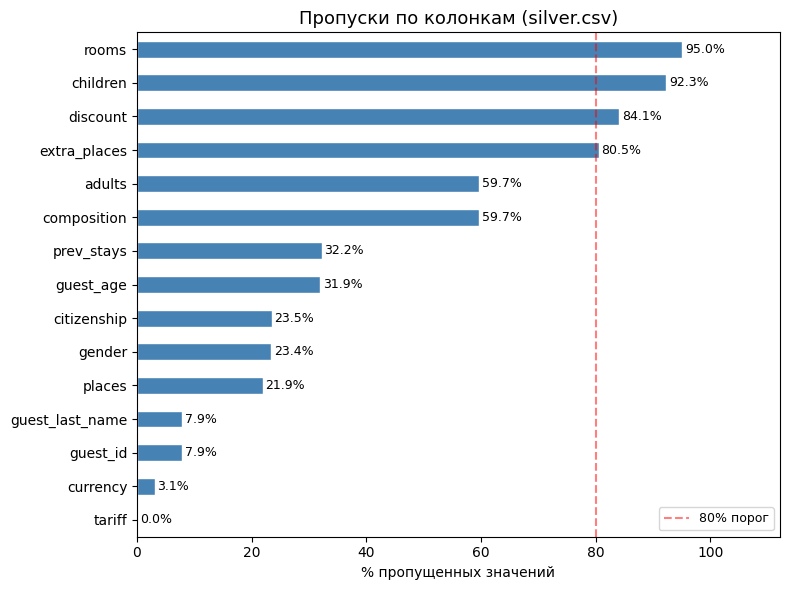

In [5]:
# Визуализация пропусков по колонкам
cols_with_nulls = (silver.isna().mean() * 100).sort_values(ascending=True)
cols_with_nulls = cols_with_nulls[cols_with_nulls > 0]

fig, ax = plt.subplots(figsize=(8, 6))
bars = cols_with_nulls.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('% пропущенных значений')
ax.set_title('Пропуски по колонкам (silver.csv)', fontsize=13)
for i, v in enumerate(cols_with_nulls):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, cols_with_nulls.max() * 1.18)
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='80% порог')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
#Приводим типы дат
for col in ['check_in_dt', 'check_out_dt', 'activity_dt']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Типы после конвертации:")
print(df[['check_in_dt', 'check_out_dt', 'activity_dt']].dtypes)
print("\nПропуски в датах:")
print(df[['check_in_dt', 'check_out_dt', 'activity_dt']].isna().sum())

Типы после конвертации:
check_in_dt     datetime64[us]
check_out_dt    datetime64[us]
activity_dt     datetime64[us]
dtype: object

Пропуски в датах:
check_in_dt     0
check_out_dt    0
activity_dt     0
dtype: int64


## 1. Фильтрация: только известные гости (`is_valid_for_rfm == 1`)

In [7]:
print("Всего строк:", len(df))
print("is_valid_for_rfm распределение:", df['is_valid_for_rfm'].value_counts().to_dict())

df = df[df['is_valid_for_rfm'] == 1].copy()
print("\nПосле фильтра:", len(df), "строк")
print("Уникальных гостей:", df['guest_id'].nunique())
print("Уникальных заездов:", df['grp_norm'].nunique())

Всего строк: 565816
is_valid_for_rfm распределение: {1: 521143, 0: 44673}

После фильтра: 521143 строк
Уникальных гостей: 447267
Уникальных заездов: 142703


## 2. Структура бронирований: grp_norm + guest_id

Один `grp_norm` может содержать несколько строк по двум разным причинам:
- **Случай 1:** несколько гостей в одном бронировании (разные `guest_id`) — норма, каждый гость остаётся отдельной строкой
- **Случай 2:** один гость с несколькими тарифными периодами (одинаковый `guest_id`) — технический артефакт, схлопывается через groupby

In [8]:
# Находим все случаи где guest_id встречается в одном grp_norm больше 1 раза
dupes = (
    df[df['guest_id'].notna()]
    .groupby(['grp_norm', 'guest_id'])
    .size()
    .reset_index(name='count')
)

dupe_pairs = dupes[dupes['count'] > 1]
print(f"Случаев дублей: {len(dupe_pairs):,}")
print(f"Распределение по count:")
print(dupe_pairs['count'].value_counts().sort_index())

Случаев дублей: 3,059
Распределение по count:
count
2     2332
3      402
4      108
5       98
6       37
7       31
8       16
9       11
10       4
11       4
12       4
13       1
14       2
15       1
16       1
17       3
18       3
21       1
Name: count, dtype: int64


In [9]:
# Смотрим конкретный пример — берём первый случай
example_grp   = dupe_pairs.iloc[0]['grp_norm']
example_guest = dupe_pairs.iloc[0]['guest_id']

example = df[
    (df['grp_norm'] == example_grp) &
    (df['guest_id'] == example_guest)
][['guest_id', 'grp_norm', 'check_in_dt', 'check_out_dt',
   'rooms', 'places', 'extra_places', 'tariff', 'composition', 'adults', 'children']]

print(f"grp_norm: {example_grp}, guest_id: {example_guest}")
print(f"Строк: {len(example)}")
example

grp_norm: 294681.0, guest_id: 1828.0
Строк: 3


,guest_id,grp_norm,check_in_dt,check_out_dt,rooms,places,extra_places,tariff,composition,adults,children
42401,1828.0,294681,2019-12-31 12:00:00,2020-01-03 12:00:00,NaN,1.0,NaN,старыйНовогодний тур с банкетом 31.12.19-03.01.20,NaN,NaN,NaN
42411,1828.0,294681,2020-01-03 12:00:00,2020-01-05 12:00:00,NaN,1.0,NaN,старый Новогодний 2022 год,2х местное размещение,2.0,NaN
46614,1828.0,294681,2019-12-30 12:00:00,2019-12-31 12:00:00,NaN,1.0,NaN,старый Новогодний 2022 год,2х местное размещение,2.0,NaN


In [10]:
# Дополнительно — смотрим ВСЮ группу (все гости в этом заезде)
# чтобы понять контекст: сколько людей всего, кто ещё был
full_group = df[df['grp_norm'] == example_grp][
    ['guest_id','grp_norm','check_in_dt', 'check_out_dt', 'guest_last_name', 'places', 'extra_places',
     'tariff', 'composition', 'adults', 'children']
]
print(f"\nВся группа {example_grp} ({len(full_group)} строк):")
full_group


Вся группа 294681.0 (6 строк):


,guest_id,grp_norm,check_in_dt,check_out_dt,guest_last_name,places,extra_places,tariff,composition,adults,children
42162,1829.0,294681,2019-12-31 12:00:00,2020-01-03 12:00:00,Фимина,1.0,NaN,старыйНовогодний тур с банкетом 31.12.19-03.01.20,2х местное размещение,2.0,NaN
42401,1828.0,294681,2019-12-31 12:00:00,2020-01-03 12:00:00,Фимин,1.0,NaN,старыйНовогодний тур с банкетом 31.12.19-03.01.20,NaN,NaN,NaN
42411,1828.0,294681,2020-01-03 12:00:00,2020-01-05 12:00:00,Фимин,1.0,NaN,старый Новогодний 2022 год,2х местное размещение,2.0,NaN
46420,1830.0,294681,2020-01-03 12:00:00,2020-01-05 12:00:00,Алексеев-2,1.0,NaN,старый Новогодний 2022 год,NaN,NaN,NaN
46568,1829.0,294681,2019-12-30 12:00:00,2019-12-31 12:00:00,Фимина,1.0,NaN,старый Новогодний 2022 год,NaN,NaN,NaN
46614,1828.0,294681,2019-12-30 12:00:00,2019-12-31 12:00:00,Фимин,1.0,NaN,старый Новогодний 2022 год,2х местное размещение,2.0,NaN


In [11]:
df['grp_norm'].count()

np.int64(521143)

In [12]:
df['grp_norm'].value_counts()[df['grp_norm'].value_counts() > 10]

grp_norm
971648     2475
961527     2112
1038932    2028
1011923    1800
1029065    1796
           ... 
971067       11
954851       11
954901       11
955660       11
984677       11
Name: count, Length: 3821, dtype: int64

In [13]:
df[df['grp_norm'] == 984677][['guest_id','grp_norm','check_in_dt', 'check_out_dt', 'guest_last_name', 'places', 'extra_places',
     'tariff', 'composition', 'adults', 'children']]

,guest_id,grp_norm,check_in_dt,check_out_dt,guest_last_name,places,extra_places,tariff,composition,adults,children
555754,1331344.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Вагау,1.0,NaN,Планета звезд январь2023,NaN,NaN,NaN
555762,1331357.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Пятакова,1.0,NaN,Планета звезд январь2023,NaN,NaN,NaN
555808,1574362.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Николенко,1.0,NaN,Планета звезд январь2023,NaN,NaN,NaN
555956,1331345.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Николенко,NaN,1.0,Планета звезд январь2023,NaN,NaN,NaN
556039,1562553.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,1562553,NaN,1.0,Планета звезд январь2023,NaN,NaN,NaN
556050,1574361.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Грекова,1.0,NaN,Планета звезд январь2023,2 Взрослых + 1 взрослый доп,3.0,NaN
556074,1574360.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Грекова,NaN,1.0,Планета звезд январь2023,NaN,NaN,NaN
556129,1574363.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Соловьева,1.0,NaN,Планета звезд январь2023,2х местное размещение,2.0,NaN
556152,1331342.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Басова,1.0,NaN,Планета звезд январь2023,2 Взрослых + 1 взрослый доп,3.0,NaN
558582,1574364.0,984677,2023-01-04 14:00:00,2023-01-07 12:00:00,Сафонова,1.0,NaN,Планета звезд январь2023,2х местное размещение,2.0,NaN


## 3. Вычисление признаков ДО схлопывания + схлопывание по (grp_norm, guest_id)

`nights` и `season` вычисляются **до** схлопывания, пока есть детальные тарифные строки.
`children` распространяется по всем гостям одного бронирования (≤ 10 человек) до схлопывания.
Затем делаем `groupby(grp_norm, guest_id)` → один заезд = одна строка.

In [14]:
# Считаем nights ДО схлопывания — каждый тарифный период отдельно
#df['nights'] = (df['check_out_dt'] - df['check_in_dt']).dt.days.clip(lower=0)

df['nights'] = (
    df['check_out_dt'].dt.normalize() - df['check_in_dt'].dt.normalize()
).dt.days.clip(lower=0)

In [15]:
# Сезон тоже считаем здесь — пока есть детальные строки
def get_season(month):
    if month in [12, 1, 2]: return 'зима'
    if month in [3, 4, 5]:  return 'весна'
    if month in [6, 7, 8]:  return 'лето'
    return 'осень'

df['season'] = df['check_in_dt'].dt.month.apply(get_season)

In [16]:
# Распространение children внутри бронирования ДО схлопывания
#
# Проблема: adults/children — атрибут НОМЕРА, а не конкретного гостя.
# В данных эти значения записаны только в ОДНОЙ строке из номера:
#   Фимина (1829): adults=2, children=NaN  ← состав номера записан здесь
#   Фимин  (1828): adults=NaN, children=NaN ← он в том же номере, но у него NaN
#
# Без исправления: 39,449 гостей с has_children=1 (занижено в 3 раза!)
# После исправления: ~134,353 гостей в бронированиях с детьми получат корректный флаг
#
# Решение: берём максимум children по всему grp_norm и отдаём всем участникам.
# Для группы ≤ 10 гостей — все участники одного бронирования с детьми = семья/родственники.
# Для крупных групп (>10 чел) — оставляем как есть: слишком неоднородный состав.

grp_size = df.groupby('grp_norm')['guest_id'].transform('nunique')
small_grp_mask = grp_size <= 10

df.loc[small_grp_mask, 'children'] = (
    df[small_grp_mask]
    .groupby('grp_norm')['children']
    .transform('max')
)

before = (df['children'] > 0).sum()
print(f"Строк с children > 0 после распространения: {before:,}")
print(f"(было ~39,449 до исправления)")

Строк с children > 0 после распространения: 132,027
(было ~39,449 до исправления)


In [17]:
# Схлопываем: один гость в одном заезде = одна строка
df_deduped = (
    df.groupby(['grp_norm', 'guest_id'], as_index=False)
    .agg(
        check_in_dt = ('check_in_dt',  'min'),
        check_out_dt= ('check_out_dt', 'max'),
        activity_dt = ('activity_dt',  'max'),
        nights      = ('nights',       'sum'),
        season      = ('season',       lambda x: x.mode().iloc[0]),
        tariff      = ('tariff',       lambda x: x.dropna().iloc[0]
                                       if x.notna().any() else None),
        room_type   = ('room_type',    lambda x: x.dropna().iloc[0]
                                       if x.notna().any() else None),
        places      = ('places',       'max'),
        children    = ('children',     'max'),
        adults      = ('adults',       'max'),
        guest_age   = ('guest_age',    'first'),
        gender      = ('gender',       'first'),
        citizenship = ('citizenship',  'first'),
        discount    = ('discount',     'mean'),
        prev_stays  = ('prev_stays',   'max'),   # атрибут гостя на дату заезда; max = корректно т.к. все строки одинаковы
    )
)

print(f"Строк до:    {len(df):,}")
print(f"Строк после: {len(df_deduped):,}")
print(f"Схлопнуто:   {len(df) - len(df_deduped):,}")

Строк до:    521,143
Строк после: 516,414
Схлопнуто:   4,729


In [18]:
# Проверка на примере Фимина
print("\nПроверка — Фимин (guest_id=1828, grp_norm=294681):")
df_deduped[
    (df_deduped['grp_norm'] == 294681.0) &
    (df_deduped['guest_id'] == 1828.0)]



Проверка — Фимин (guest_id=1828, grp_norm=294681):


,grp_norm,guest_id,check_in_dt,check_out_dt,activity_dt,nights,season,tariff,room_type,places,children,adults,guest_age,gender,citizenship,discount,prev_stays
852,294681,1828.0,2019-12-30 12:00:00,2020-01-05 12:00:00,2020-01-05 12:00:00,6,зима,старыйНовогодний тур с банкетом 31.12.19-03.01.20,СТД-СТАНДАРТ,1.0,NaN,2.0,58.0,Мужской,РОССИЯ,NaN,8.0


## 4.5 Анализ выбросов по длительности пребывания (nights)

Перед финальной фильтрацией смотрим на распределение `nights` в `df_deduped`, чтобы выбрать разумную границу.

In [19]:
print(df_deduped['nights'].describe())

count    516414.000000
mean          8.426265
std          11.872083
min           0.000000
25%           3.000000
50%           6.000000
75%          13.000000
max        2024.000000
Name: nights, dtype: float64


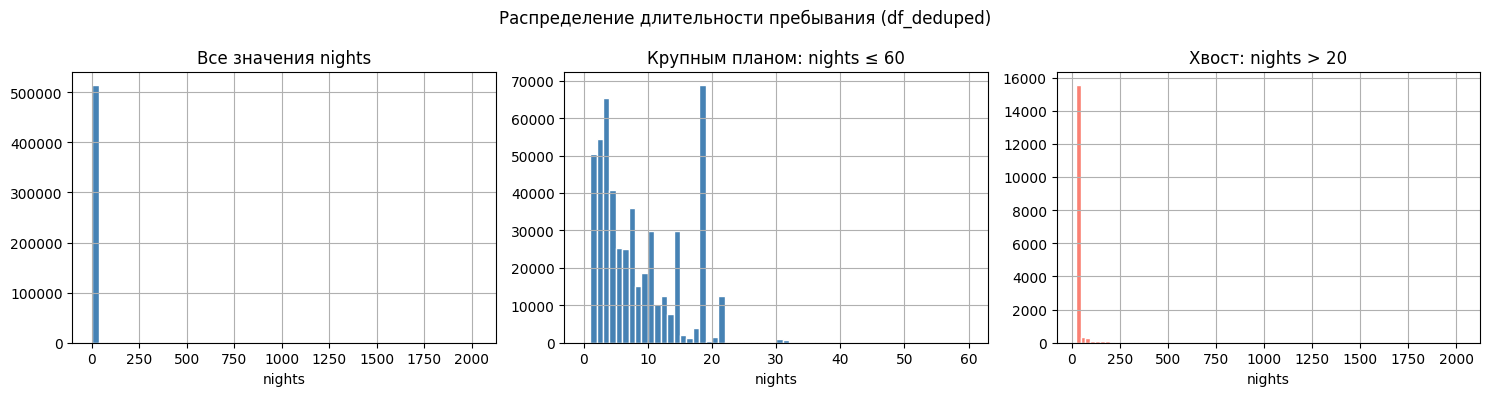

Квантили nights (df_deduped):
  p 50: 6 ночей
  p 75: 13 ночей
  p 90: 18 ночей
  p 95: 18 ночей
  p 97: 21 ночей
  p 99: 21 ночей
  p 99: 122 ночей


In [20]:
# Распределение nights после схлопывания — ищем естественную границу для фильтрации
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_deduped['nights'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Все значения nights')
axes[0].set_xlabel('nights')

df_deduped[df_deduped['nights'] <= 60]['nights'].hist(bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Крупным планом: nights ≤ 60')
axes[1].set_xlabel('nights')

df_deduped[df_deduped['nights'] > 20]['nights'].hist(bins=80, ax=axes[2], color='salmon', edgecolor='white')
axes[2].set_title('Хвост: nights > 20')
axes[2].set_xlabel('nights')

plt.suptitle('Распределение длительности пребывания (df_deduped)', fontsize=12)
plt.tight_layout()
plt.show()

print("Квантили nights (df_deduped):")
for q in [0.5, 0.75, 0.9, 0.95, 0.97, 0.99, 0.999]:
    print(f"  p{int(q*100):3d}: {df_deduped['nights'].quantile(q):.0f} ночей")

In [21]:
# Фильтрация аномальных nights
print(f"Строк с nights > 90: {(df_deduped['nights'] > 90).sum()}")
print(f"Строк с nights == 0: {(df_deduped['nights'] == 0).sum()}")
print("Топ-5 максимальных nights:", df_deduped['nights'].sort_values(ascending=False).head(5).values)


Строк с nights > 90: 734
Строк с nights == 0: 190
Топ-5 максимальных nights: [2024 2024 2024 1212 1212]


In [22]:
# Смотрим что за строки с nights == 0
zero_nights = df_deduped[df_deduped['nights'] == 0]
print("Примеры строк с nights=0:")
print(zero_nights[['guest_id', 'grp_norm', 'check_in_dt', 
                    'check_out_dt', 'nights', 'tariff']].head(10))

print("\nТарифы у нулевых ночей (топ-10):")
print(zero_nights['tariff'].value_counts().head(10))

Примеры строк с nights=0:
        guest_id  grp_norm         check_in_dt        check_out_dt  nights  \
9405   1311586.0    900036 2019-11-29 12:00:00 2019-11-29 17:00:00       0   
9406   1311587.0    900036 2019-11-29 12:00:00 2019-11-29 17:00:00       0   
10269  1312293.0    900474 2019-12-01 12:00:00 2019-12-01 23:59:00       0   
10321  1312260.0    900513 2019-12-03 12:00:00 2019-12-03 23:59:00       0   
15865     4852.0    901211 2019-12-11 12:00:00 2019-12-11 23:59:00       0   
63008  1358139.0    920003 2020-10-11 12:02:00 2020-10-11 23:00:00       0   
64009  1358949.0    920374 2020-10-26 00:00:00 2020-10-26 12:00:00       0   
64030  1356957.0    920391 2020-10-21 00:01:00 2020-10-21 12:00:00       0   
64168  1359908.0    920474 2020-10-30 12:00:00 2020-10-30 16:30:00       0   
64169  1359909.0    920474 2020-10-30 12:00:00 2020-10-30 16:30:00       0   

                                tariff  
9405            Служебный (с питанием)  
9406            Служебный (с пита

In [23]:
# Смотрим что за строки с nights > 90
long_nights = df_deduped[df_deduped['nights'] > 90]
print(f"Строк с nights > 90: {len(long_nights)}")
print("\nПримеры строк с nights > 90:")
print(long_nights[['guest_id', 'grp_norm', 'check_in_dt',
                    'check_out_dt', 'nights', 'tariff']].head(10))

print("\nТарифы у аномально длинных заездов (топ-10):")
print(long_nights['tariff'].value_counts().head(10))

Строк с nights > 90: 734

Примеры строк с nights > 90:
        guest_id  grp_norm         check_in_dt        check_out_dt  nights  \
0         7234.0    271557 2020-01-01 00:00:00 2021-01-01 00:00:00     366   
1729      5327.0    297588 2019-12-20 00:00:00 2020-12-31 00:00:00     377   
5094      1596.0    299615 2019-12-31 00:00:00 2020-12-31 00:00:00     366   
6545      5485.0    300258 2019-01-01 12:00:00 2020-01-03 12:00:00     367   
10025  1312102.0    900307 2019-11-30 12:00:00 2020-02-29 12:00:00      91   
19913  1320737.0    901649 2019-12-15 14:00:00 2020-04-15 12:00:00     122   
21504  1315896.0    902319 2019-11-25 12:00:00 2020-02-25 12:00:00      92   
21914  1316293.0    902528 2019-12-30 12:00:00 2020-03-31 12:00:00      92   
23138  1318315.0    903047 2020-06-05 14:00:00 2020-12-31 12:00:00     209   
25638  1321406.0    903923 2020-01-16 12:00:00 2020-12-31 12:00:00     350   

                                                  tariff  
0                          

## 4. Удаление служебных записей

Из `df_deduped` убираем тарифы сотрудников (`Служебный`, `СОТРУДНИКИ`, `Сотрудник`) — они не являются клиентами санатория и искажают кластеризацию.

In [24]:
# Убираем только служебные и сотрудников
service_mask = df_deduped['tariff'].str.contains(
    'Служебный|СОТРУДНИКИ|Сотрудник',
    case=False, na=False
)

n_before = len(df_deduped)
df_deduped = df_deduped[~service_mask].copy()

print(f"Убрано служебных строк: {n_before - len(df_deduped):,}")
print(f"Осталось строк: {len(df_deduped):,}")

# Проверка что НАРОДНЫЙ остался
print(f"\nНАРОДНЫЙ после фильтра: {(df_deduped['tariff'] == 'НАРОДНЫЙ').sum()}")

Убрано служебных строк: 29,196
Осталось строк: 487,218

НАРОДНЫЙ после фильтра: 1837


## 5. Инжиниринг признаков

Строим финальный датасет для кластеризации. Каждый шаг (N1–N8) добавляет или уточняет признаки.

In [25]:
# N1: Финальная очистка nights → df_clean
# nights==0: заселение и выезд в один день — не полноценный заезд (например: прибыл в 14:00, уехал в 17:00)
# nights>90: 19 аномальных строк (367 ночей у "Новогоднего тура" — ошибка дат в системе)
print("Перед очисткой:")
print(f"  nights == 0: {(df_deduped['nights'] == 0).sum()} строк")
print(f"  nights >  90: {(df_deduped['nights'] > 90).sum()} строк")

df_clean = df_deduped[
    (df_deduped['nights'] > 0) & (df_deduped['nights'] <= 90)
].copy()

print(f"\ndf_clean: {len(df_clean):,} строк")
print(f"Уникальных гостей: {df_clean['guest_id'].nunique():,}")
print(df_clean['nights'].describe().round(1))

Перед очисткой:
  nights == 0: 144 строк
  nights >  90: 19 строк

df_clean: 487,055 строк
Уникальных гостей: 437,519
count    487055.0
mean          8.3
std           6.1
min           1.0
25%           3.0
50%           7.0
75%          13.0
max          89.0
Name: nights, dtype: float64


In [26]:
# N2: lead_time — горизонт бронирования (дней до заезда)
# Бизнес-ценность:
#   короткий lead_time ("спонтанные") → таргетировать last-minute акциями в периоды недозагруженности
#   длинный lead_time ("планировщики") → ранние предложения, акции "раннего бронирования"

df['created_dt'] = pd.to_datetime(df['created_dt'], errors='coerce')

created = (
    df.groupby(['grp_norm', 'guest_id'])['created_dt']
    .min()
    .reset_index()
)
df_clean = df_clean.merge(created, on=['grp_norm', 'guest_id'], how='left')
df_clean['lead_time'] = (
    df_clean['check_in_dt'] - df_clean['created_dt']
).dt.days.clip(lower=0)

print(f"Пропуски created_dt: {df_clean['created_dt'].isna().sum()}")
print("\nlead_time:")
print(df_clean['lead_time'].describe().round(1))
print("\nКвантили:")
for q in [0.25, 0.5, 0.75, 0.9, 0.95]:
    print(f"  p{int(q*100):2d}: {df_clean['lead_time'].quantile(q):.0f} дней")

Пропуски created_dt: 0

lead_time:
count    487055.0
mean         78.2
std          84.9
min           0.0
25%          14.0
50%          45.0
75%         118.0
max         689.0
Name: lead_time, dtype: float64

Квантили:
  p25: 14 дней
  p50: 45 дней
  p75: 118 дней
  p90: 206 дней
  p95: 255 дней


In [27]:
# N3: Очистка guest_age
# 999 — заглушка для неизвестного возраста
# >100 — явные аномалии данных (max=976 в сырых данных)
import numpy as np

print(f"Значение 999 в guest_age: {(df_clean['guest_age'] == 999).sum()} строк")
print(f"Значений > 100: {(df_clean['guest_age'] > 100).sum()} строк")
df_clean['guest_age'] = df_clean['guest_age'].replace(999, np.nan).astype(float)
df_clean.loc[df_clean['guest_age'] > 100, 'guest_age'] = np.nan
print(f"Пропуски guest_age после очистки: {df_clean['guest_age'].isna().sum():,} ({df_clean['guest_age'].isna().mean()*100:.1f}%)")
print(df_clean['guest_age'].describe().round(1))

Значение 999 в guest_age: 419 строк
Значений > 100: 795 строк
Пропуски guest_age после очистки: 128,071 (26.3%)
count    358984.0
mean         39.0
std          22.1
min           1.0
25%          16.0
50%          40.0
75%          57.0
max         100.0
Name: guest_age, dtype: float64


In [53]:
# N4: tariff_group — группировка 628 уникальных тарифов в 8 категорий
# Бизнес-ценность: tariff_group = ценовой сегмент гостя.
# Разные группы → разные маркетинговые офферы для заполнения недозагруженности:
#   льготный/корп    → B2B: партнёрские программы с предприятиями/ФСС/Согаз
#   ультра/all-incl  → туристы с высоким чеком, "всё включено"
#   стандарт/оптима  → массовый сегмент, основа загрузки
#   лечебный         → санаторно-курортные путёвки, специфичная аудитория
#   новогодний/банкет → праздничный сегмент (сезонный, высокий спрос)
#   фестиваль/событие → групповые мероприятия, турниры, сборы
#   социальный       → школьники, студенты, "серебряный возраст"

# Сначала удаляем административные записи "НЕ СЕЛИТЬ"
admin_mask = df_clean['tariff'].str.contains('НЕ СЕЛИТЬ|не селить', case=False, na=False)
print(f"Административных записей 'НЕ СЕЛИТЬ': {admin_mask.sum()}")
df_clean = df_clean[~admin_mask].copy()

def map_tariff(t):
    if pd.isna(t): return 'other'
    t = t.lower()
    if any(x in t for x in ['фсс', 'гку', 'согаз', 'дирекци', 'народн',
                              'нефтегаз', 'газпром', 'юганск', 'корпор']):
        return 'льготный/корп'
    if any(x in t for x in ['ультра', 'все включено']):
        return 'ультра/all-incl'
    if any(x in t for x in ['оптима', 'стандарт', 'межсезон', 'стд']):
        return 'стандарт/оптима'
    if any(x in t for x in ['новогодн', 'банкет', 'праздн', 'майский']):
        return 'новогодний/банкет'
    if any(x in t for x in ['лечени', 'оздоров', 'санатор', 'медцентр',
                              'скл', 'профмед']):          # ← добавили
        return 'лечебный'
    if any(x in t for x in ['фестивал', 'шахмат', 'шашк', 'сборы',
                              'планета', 'турнир', 'выходного дня',
                              'крок', 'азимут']):           # ← добавили
        return 'событие/группы'
    if any(x in t for x in ['школьн', 'студент', 'серебрян', 'золотая',
                              'мечтай', 'возраст', 'каникул']):  # ← добавили
        return 'социальный'
    if any(x in t for x in ['аквапарк', 'акция', 'спецпредл',
                              'майский', 'лазурный', 'пляжный',
                              'открытый юг', 'доступный юг']):   # ← добавили
        return 'акция/спецпредл'
    if any(x in t for x in ['первенство', 'роза ветров', 'фшр', 'каратэ',
                          'турнир', 'чемпион', 'кубок']):
        return 'событие/группы'

    if any(x in t for x in ['кузбасс', 'нпз', 'фсэтр', 'яцков',
                          'биглион']):
        return 'льготный/корп'

    if any(x in t for x in ['радость планеты']):
        return 'социальный'

    if any(x in t for x in ['гу ', 'гу-', 'краснодарское', 'ростовское',
                          'тверское', 'офср', 'турмаг', 'иргашев']):
        return 'льготный/корп'
    
    if any(x in t for x in ['развитие', 'артбифэмили', 'кадеты',
                              'будущее планеты', 'ребёнок', 'ребенок']):
        return 'социальный'    
    return 'other'

df_clean['tariff_group'] = df_clean['tariff'].apply(map_tariff)
print("\ntariff_group распределение:")
print(df_clean['tariff_group'].value_counts())
print(f"\nПокрытие (не 'other'): {(df_clean['tariff_group'] != 'other').mean()*100:.1f}%")

# Остаток 'other' — для контроля
other_left = df_clean[df_clean['tariff_group'] == 'other']['tariff'].value_counts().head(10)
print(f"\nТоп-10 оставшихся в 'other':")
print(other_left.to_string())

Административных записей 'НЕ СЕЛИТЬ': 0

tariff_group распределение:
tariff_group
ультра/all-incl      197353
льготный/корп        111131
стандарт/оптима       64125
событие/группы        41973
новогодний/банкет     23770
социальный            17215
other                 16640
лечебный               7818
акция/спецпредл        5872
Name: count, dtype: int64

Покрытие (не 'other'): 96.6%

Топ-10 оставшихся в 'other':
tariff
Овация Триумф июнь,август    430
"Силовые Агрегаты"           426
ГОРЯЧИЕ НЕДЕЛИ               413
Карате июнь(3-хместн.)       406
Милигрина                    405
Левел ап                     385
Автоваз                      376
Золотой Дельфин              372
Дарфест                      339
Горящее предложение          338


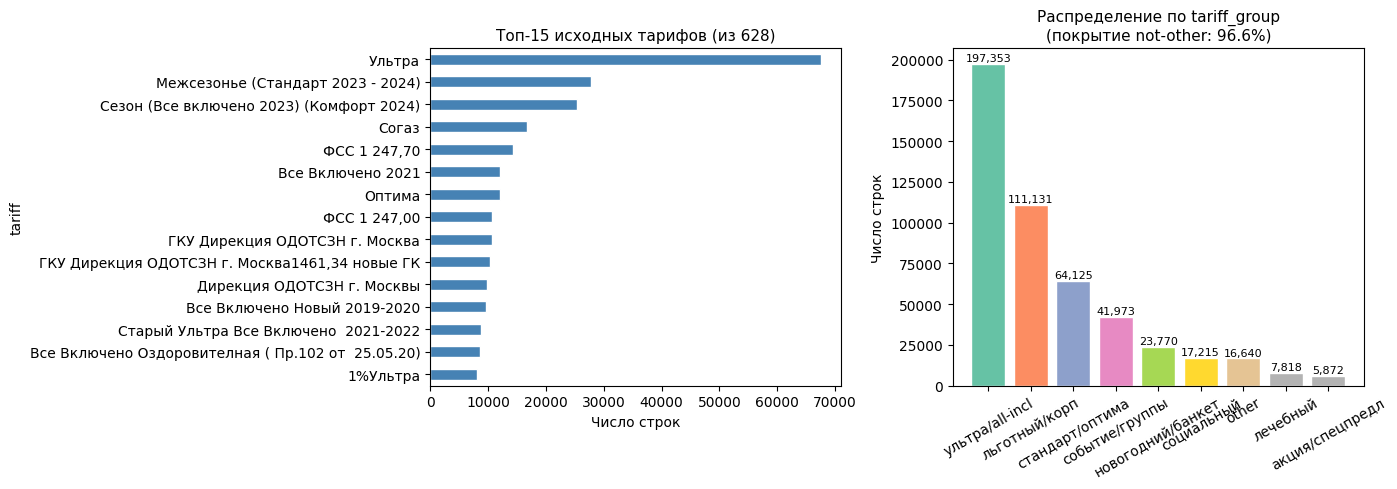

In [54]:
# Визуализация: распределение тарифных групп
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Топ-15 исходных тарифов
top_tariffs = df_clean['tariff'].value_counts().head(15)
top_tariffs[::-1].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Топ-15 исходных тарифов (из 628)', fontsize=11)
axes[0].set_xlabel('Число строк')

# Распределение по группам
tg = df_clean['tariff_group'].value_counts()
colors = [plt.cm.Set2(i) for i in range(len(tg))]
bars = axes[1].bar(tg.index, tg.values, color=colors, edgecolor='white')
axes[1].set_title(
    f'Распределение по tariff_group\n'
    f'(покрытие not-other: {(df_clean["tariff_group"] != "other").mean()*100:.1f}%)',
    fontsize=11
)
axes[1].set_ylabel('Число строк')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [51]:
# N5: Анализ room_type — смотрим все уникальные значения перед группировкой
print(f"Уникальных room_type: {df_clean['room_type'].nunique()}")
print("\nВсе значения room_type (по убыванию частоты):")
print(df_clean['room_type'].value_counts(dropna=False).to_string())

Уникальных room_type: 24

Все значения room_type (по убыванию частоты):
room_type
СТД-СТАНДАРТ                           273464
К+- Комфорт+                            97904
К -Комфорт                              80458
К-VS - VS-Комфорт                       11142
СТДVS - VS-СТАНДАРТ                     10457
К+VS - VS-Комфорт+                       3076
КфМрс - Комфорт Морской                  2481
ЛК3-ЛЮКС 3 КОМНАТЫ                       2304
ЛК3VS - VS-ЛЮКС 3 КОМНАТЫ                1544
АПАРТ-АПАРТАМЕНТЫ                        1458
ЛК2-ЛЮКС 2 КОМНАТЫ                        450
ЛК2VS - VS-ЛЮКС 2 КОМНАТЫ                 328
АПVS - VS-АПАРТАМЕНТЫ                     218
ЛЮКС                                      208
Брлн-Берлин                               108
СТД 2 - СТД2-СТАНДАРТ(2-222, 2-227)        87
АП+ - АПАРТ ПЛЮС 1-НО КОМНАТНЫЙ            84
АП+3К - 3 -Х КОМНАТНЫЙ                     42
МРСК - Морская прохлада (К+)               32
СЛУЖБ-СЛУЖЕБНЫЙ                            1

In [31]:
# N6: room_group — группировка типов номеров (5 категорий)
# Бизнес-ценность: тип номера определяет, какой сегмент гостей может закрыть недозагруженность
# конкретного номерного фонда (например, пустые люксы → привлечь сегмент "высокий чек")

def map_room(r):
    if pd.isna(r): return 'unknown'
    r = r.lower()
    if any(x in r for x in ['люкс', 'lux', 'suite', 'полулюкс']): return 'люкс'
    if 'комфорт' in r:                                              return 'комфорт'
    if any(x in r for x in ['стандарт', 'стд']):                   return 'стандарт'
    if any(x in r for x in ['апарт', 'берлин']):                   return 'апартаменты'
    if any(x in r for x in ['эконом', 'бюджет']):                  return 'эконом'
    return 'other'

df_clean['room_group'] = df_clean['room_type'].apply(map_room)
print("room_group распределение:")
print(df_clean['room_group'].value_counts(dropna=False))
print(f"\nПокрытие (не 'other'/'unknown'): "
      f"{(~df_clean['room_group'].isin(['other', 'unknown'])).mean()*100:.1f}%")

room_group распределение:
room_group
стандарт       284008
комфорт        195069
люкс             4834
апартаменты      1897
other              89
Name: count, dtype: int64

Покрытие (не 'other'/'unknown'): 100.0%


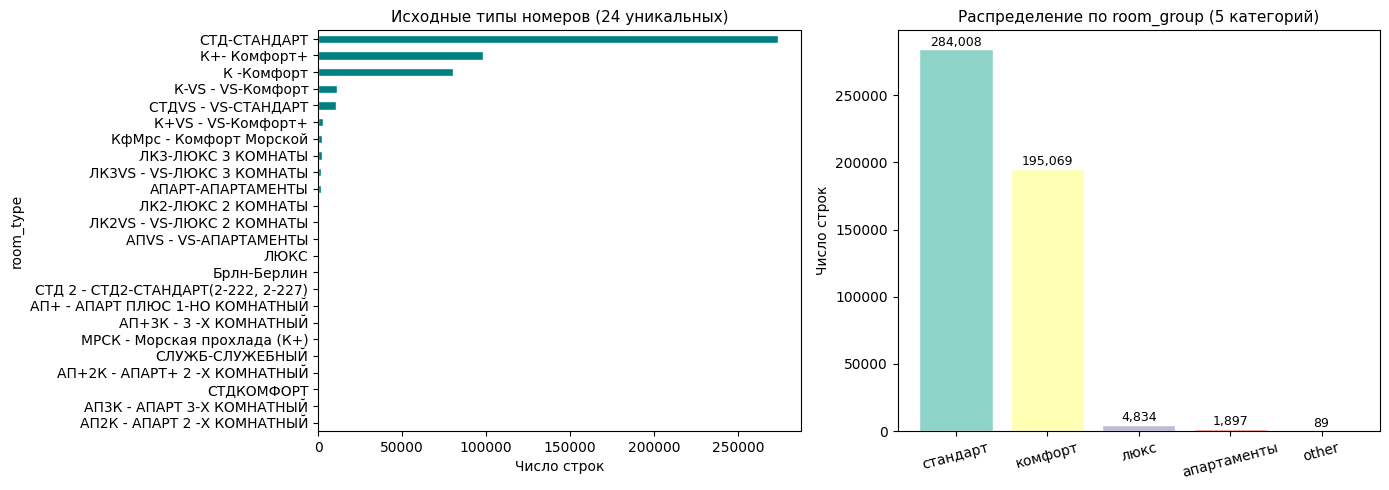

In [32]:
# Визуализация: группировка типов номеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Все исходные типы номеров
room_counts = df_clean['room_type'].value_counts()
room_counts[::-1].plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title(f'Исходные типы номеров ({df_clean["room_type"].nunique()} уникальных)', fontsize=11)
axes[0].set_xlabel('Число строк')

# После группировки
rg = df_clean['room_group'].value_counts()
colors = [plt.cm.Set3(i) for i in range(len(rg))]
bars = axes[1].bar(rg.index, rg.values, color=colors, edgecolor='white')
axes[1].set_title('Распределение по room_group (5 категорий)', fontsize=11)
axes[1].set_ylabel('Число строк')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# N7: Бинарные признаки + сезонность
# Каждый признак — маркетинговый сигнал для выбора стратегии заполнения недозагруженности
import numpy as np

# has_discount: вычисляем как колонку для анализа, но в признаки НЕ включаем
# → дублирует discount_rate (corr=0.86); при евклидовых расстояниях даёт двойной вес скидке
df_clean['has_discount']   = (df_clean['discount'] > 0).astype(int)

# discount_rate: размер скидки (0 если не было) — ценовая чувствительность не бинарная
# Скидка 5% и скидка 50% — разные поведенческие профили
df_clean['discount_rate']  = df_clean['discount'].clip(0, 100).fillna(0)

# has_children: приезжал с детьми → семейный сегмент → нужны семейные номера и программы
df_clean['has_children']   = (df_clean['children'] > 0).astype(int)

# is_weekend_in: заезд в пятницу или субботу → weekend-турист (короткий отдых, иная мотивация)
df_clean['is_weekend_in']  = df_clean['check_in_dt'].dt.dayofweek.isin([4, 5]).astype(int)

# Примечание: is_repeat и is_partner удалены — они дублируют prev_stays и tariff_group соответственно
# KMeans с евклидовой метрикой не должен учитывать одну информацию дважды

# Циклическое кодирование месяца: декабрь (12) и январь (1) должны быть "рядом"
# sin/cos позволяет KMeans корректно считать расстояния между месяцами
df_clean['check_in_month'] = df_clean['check_in_dt'].dt.month
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['check_in_month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['check_in_month'] / 12)

# has_discount в признаки не входит — только для справки
bin_features = ['has_children', 'is_weekend_in']
print("Доли бинарных признаков (%):")
print((df_clean[bin_features].mean() * 100).round(1).to_string())
print(f"\nhas_discount (для справки, не признак): {df_clean['has_discount'].mean()*100:.1f}%")
print(f"\ndiscount_rate (описательная статистика):")
print(df_clean['discount_rate'].describe().round(1))
print(f"\nЦиклическое кодирование месяца (month_sin, month_cos) — проверка крайних месяцев:")
check = df_clean[['check_in_month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('check_in_month')
print(check.to_string(index=False))

Доли бинарных признаков (%):
has_children     26.9
is_weekend_in    31.5

has_discount (для справки, не признак): 16.3%

discount_rate (описательная статистика):
count    485897.0
mean          2.2
std           5.7
min           0.0
25%           0.0
50%           0.0
75%           0.0
max         100.0
Name: discount_rate, dtype: float64

Циклическое кодирование месяца (month_sin, month_cos) — проверка крайних месяцев:
 check_in_month     month_sin     month_cos
              1  5.000000e-01  8.660254e-01
              2  8.660254e-01  5.000000e-01
              3  1.000000e+00  6.123234e-17
              4  8.660254e-01 -5.000000e-01
              5  5.000000e-01 -8.660254e-01
              6  1.224647e-16 -1.000000e+00
              7 -5.000000e-01 -8.660254e-01
              8 -8.660254e-01 -5.000000e-01
              9 -1.000000e+00 -1.836970e-16
             10 -8.660254e-01  5.000000e-01
             11 -5.000000e-01  8.660254e-01
             12 -2.449294e-16  1.000000e+00


In [34]:
# N8: Итоговая сводка финального датасета для кластеризации
df_clean = df_clean.rename(columns={'nights': 'stay_duration'})

# num_features: числовые (включая discount_rate и циклические month_sin/month_cos)
# cat_features: категориальные (check_in_month убран — заменён на month_sin/month_cos)
# bin_features: бинарные
#   УДАЛЕНО has_discount: дублирует discount_rate (corr=0.86) → двойной вес скидке в KMeans
#   УДАЛЕНО is_repeat, is_partner: дублировали prev_stays и tariff_group
num_features = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos']
cat_features  = ['tariff_group', 'room_group', 'gender']
bin_features  = ['has_children', 'is_weekend_in']
all_features  = num_features + cat_features + bin_features

print(f"=== Финальный датасет df_clean ===")
print(f"Строк: {len(df_clean):,}  |  Признаков для кластеризации: {len(all_features)}")
print(f"\n--- Числовые признаки ---")
print(df_clean[num_features].describe().round(1))
print(f"\n--- Пропуски в признаках ---")
miss = df_clean[all_features].isna().sum()
miss_pct = (miss / len(df_clean) * 100).round(1)
miss_df = pd.DataFrame({'count': miss, '%': miss_pct})
print(miss_df[miss_df['count'] > 0].to_string())
print(f"\n--- Категориальные признаки ---")
for f in cat_features:
    vc = df_clean[f].value_counts(dropna=False)
    print(f"\n{f}:")
    print(vc.to_string())
print(f"\n--- Бинарные признаки (доля 1, %) ---")
print((df_clean[bin_features].mean() * 100).round(1).to_string())

=== Финальный датасет df_clean ===
Строк: 485,897  |  Признаков для кластеризации: 12

--- Числовые признаки ---
       stay_duration  lead_time  guest_age  prev_stays  discount_rate  \
count       485897.0   485897.0   358952.0    355126.0       485897.0   
mean             8.3       78.3       39.0         2.3            2.2   
std              6.1       84.9       22.1         5.9            5.7   
min              1.0        0.0        1.0         1.0            0.0   
25%              3.0       14.0       16.0         1.0            0.0   
50%              7.0       45.0       40.0         1.0            0.0   
75%             13.0      118.0       57.0         2.0            0.0   
max             89.0      689.0      100.0       648.0          100.0   

       month_sin  month_cos  
count   485897.0   485897.0  
mean        -0.0       -0.1  
std          0.7        0.7  
min         -1.0       -1.0  
25%         -0.9       -0.9  
50%          0.0       -0.0  
75%          0.5   

## 6. Отбор признаков для кластеризации → df_model

In [35]:
id_cols      = ['guest_id', 'grp_norm']
num_features = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos']
cat_features = ['tariff_group', 'room_group', 'gender']
bin_features = ['has_children', 'is_weekend_in']
all_features = num_features + cat_features + bin_features

df_model = df_clean[id_cols + all_features].copy()

print(f"df_model: {df_model.shape[0]:,} строк × {df_model.shape[1]} колонок")
print(f"  идентификаторы : {id_cols}")
print(f"  числовые       : {num_features}")
print(f"  категориальные : {cat_features}")
print(f"  бинарные       : {bin_features}")
print(f"\nПропуски:")
miss = df_model[all_features].isna().sum()
print(miss[miss > 0].to_frame('count').assign(pct=(miss[miss > 0] / len(df_model) * 100).round(1)).to_string())
print(f"\nИзменения vs. предыдущей версии:")
print("  УДАЛЕНО: has_discount (дубль discount_rate, corr=0.86)")
print("  УДАЛЕНО: is_repeat (дубль prev_stays), is_partner (дубль tariff_group), check_in_month (числовой)")
print("  ДОБАВЛЕНО: discount_rate (размер скидки), month_sin + month_cos (циклич. кодирование месяца)")

df_model: 485,897 строк × 14 колонок
  идентификаторы : ['guest_id', 'grp_norm']
  числовые       : ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos']
  категориальные : ['tariff_group', 'room_group', 'gender']
  бинарные       : ['has_children', 'is_weekend_in']

Пропуски:
             count   pct
guest_age   126945  26.1
prev_stays  130771  26.9
gender       83656  17.2

Изменения vs. предыдущей версии:
  УДАЛЕНО: has_discount (дубль discount_rate, corr=0.86)
  УДАЛЕНО: is_repeat (дубль prev_stays), is_partner (дубль tariff_group), check_in_month (числовой)
  ДОБАВЛЕНО: discount_rate (размер скидки), month_sin + month_cos (циклич. кодирование месяца)


## 7. Анализ мультиколлинеарности и пропусков (df_model)

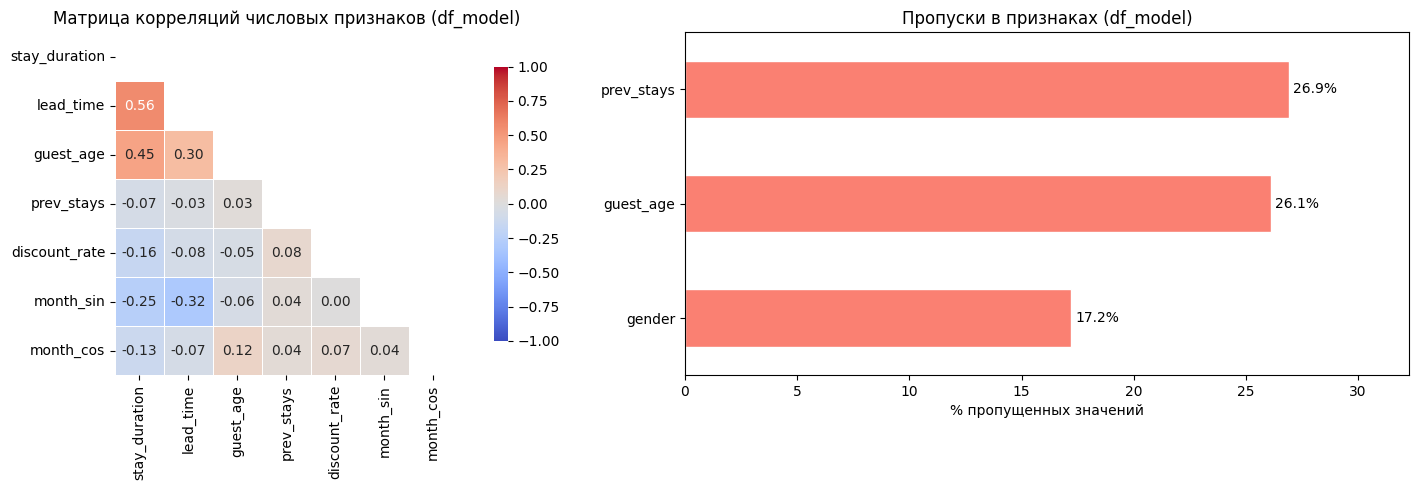


=== Признаки, исключённые из X из-за дублирования ===
  ✗ has_discount: corr=0.86 с discount_rate → двойной вес скидки в KMeans
  ✗ is_repeat: бинаризация prev_stays — менее информативна
  ✗ is_partner: перекрывается с tariff_group (льготный/корп)
  ✗ n_stays: corr=0.74 с prev_stays; prev_stays предпочтительнее (CRM-история)
  ✗ check_in_month: заменён на month_sin/month_cos (циклическое кодирование)


In [36]:
num_features_for_corr = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays',
                          'discount_rate', 'month_sin', 'month_cos']

corr = df_model[num_features_for_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap корреляций
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Матрица корреляций числовых признаков (df_model)', fontsize=12)

# Пропуски по признакам
miss_pct = (df_model[all_features].isna().mean() * 100).round(1).sort_values(ascending=True)
miss_pct = miss_pct[miss_pct > 0]
if len(miss_pct) > 0:
    miss_pct.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
    axes[1].set_xlabel('% пропущенных значений')
    axes[1].set_title('Пропуски в признаках (df_model)', fontsize=12)
    for i, v in enumerate(miss_pct):
        axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
    axes[1].set_xlim(0, miss_pct.max() * 1.2)
else:
    axes[1].text(0.5, 0.5, 'Пропусков нет', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Пропуски в признаках (df_model)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n=== Признаки, исключённые из X из-за дублирования ===")
excluded = {
    'has_discount':   'corr=0.86 с discount_rate → двойной вес скидки в KMeans',
    'is_repeat':      'бинаризация prev_stays — менее информативна',
    'is_partner':     'перекрывается с tariff_group (льготный/корп)',
    'n_stays':        'corr=0.74 с prev_stays; prev_stays предпочтительнее (CRM-история)',
    'check_in_month': 'заменён на month_sin/month_cos (циклическое кодирование)',
}
for feat, reason in excluded.items():
    print(f"  ✗ {feat}: {reason}")

## 8. Агрегация до уровня гостя → df_for_model_claster

Цель — **сегментация клиентов**, а не заездов. Один гость = одна строка.

Правила агрегации:
- Числовые → `mean` (средний профиль гостя по всем заездам)
- `prev_stays` → `max` (накопленная CRM-активность: ≈ число заездов, включая историю до 2019)
- `guest_age`, `gender` → `first` (атрибут гостя, не меняется)
- Категориальные → `mode` (самый частый тариф/номер)
- `has_children` → `max` (1 если хоть раз приезжал с детьми)
- `is_weekend_in` → `mean` (доля заездов в пятницу/субботу)

In [37]:
# Агрегация df_model до уровня гостя
# Каждый гость = одна строка (цель — сегментация клиентов, не заездов)

num_cat_bin = {
    'stay_duration': 'mean',
    'lead_time':     'mean',
    'guest_age':     'first',
    'prev_stays':    'max',
    'discount_rate': 'mean',
    'month_sin':     'mean',
    'month_cos':     'mean',
    'gender':        'first',
    'has_children':  'max',
    'is_weekend_in': 'mean',
}
cat_agg = {
    'tariff_group': lambda x: x.mode().iloc[0],
    'room_group':   lambda x: x.mode().iloc[0],
}

g = df_model.groupby('guest_id')
df_for_model_claster = g.agg(num_cat_bin)
df_for_model_claster[['tariff_group', 'room_group']] = g[['tariff_group', 'room_group']].agg(cat_agg)

# n_stays — количество заездов в датасете; хранится как метаданные, НЕ включается в признаки X
# (высокая корреляция с prev_stays=0.74; prev_stays предпочтительнее — из CRM, учитывает всю историю)
df_for_model_claster['n_stays'] = g['stay_duration'].count()

df_for_model_claster = df_for_model_claster.reset_index()

df_for_model_claster['stay_duration'] = df_for_model_claster['stay_duration'].round(1)
df_for_model_claster['lead_time']     = df_for_model_claster['lead_time'].round(1)
df_for_model_claster['discount_rate'] = df_for_model_claster['discount_rate'].round(2)

print(f"df_for_model_claster: {df_for_model_claster.shape[0]:,} гостей × {df_for_model_claster.shape[1]} колонок")
print(f"(было {len(df_model):,} строк-заездов)")
print(f"\nКолонки: {list(df_for_model_claster.columns)}")
print(f"\nПропуски:")
miss = df_for_model_claster.isna().sum()
miss_pct = (miss / len(df_for_model_claster) * 100).round(1)
miss_df = pd.DataFrame({'count': miss, '%': miss_pct})
print(miss_df[miss_df['count'] > 0].to_string())
print(f"\nОписательная статистика (до log-трансформации):")
num_cols = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'n_stays']
print(df_for_model_claster[num_cols].describe().round(1))

df_for_model_claster: 436,492 гостей × 14 колонок
(было 485,897 строк-заездов)

Колонки: ['guest_id', 'stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos', 'gender', 'has_children', 'is_weekend_in', 'tariff_group', 'room_group', 'n_stays']

Пропуски:
             count     %
guest_age   121506  27.8
prev_stays  124983  28.6
gender       82567  18.9

Описательная статистика (до log-трансформации):
       stay_duration  lead_time  guest_age  prev_stays  discount_rate  \
count       436492.0   436492.0   314986.0    311509.0       436492.0   
mean             8.4       78.4       38.7         1.5            2.1   
std              6.0       83.7       22.2         2.6            5.5   
min              1.0        0.0        1.0         1.0            0.0   
25%              3.0       15.0       16.0         1.0            0.0   
50%              7.0       47.0       40.0         1.0            0.0   
75%             14.0      118.0       57.0 

In [38]:
df_for_model_claster.head()

,guest_id,stay_duration,lead_time,guest_age,prev_stays,discount_rate,month_sin,month_cos,gender,has_children,is_weekend_in,tariff_group,room_group,n_stays
0,15.0,8.0,12.0,NaN,NaN,10.0,-2.449294e-16,1.000000e+00,NaN,0,0.000000,новогодний/банкет,стандарт,1
1,36.0,3.0,13.0,NaN,NaN,0.0,8.660254e-01,5.000000e-01,NaN,0,1.000000,ультра/all-incl,стандарт,1
2,61.0,11.0,38.5,73.0,4.0,5.0,5.000000e-01,0.000000e+00,Женский,1,0.000000,other,стандарт,2
3,72.0,9.7,9.3,36.0,6.0,0.0,1.220085e-01,4.553418e-01,Мужской,0,0.333333,other,комфорт,3
4,73.0,9.3,27.0,16.0,3.0,0.0,5.773503e-01,1.480297e-16,Мужской,0,0.333333,событие/группы,стандарт,3


In [39]:
df_for_model_claster.columns

Index(['guest_id', 'stay_duration', 'lead_time', 'guest_age', 'prev_stays',
       'discount_rate', 'month_sin', 'month_cos', 'gender', 'has_children',
       'is_weekend_in', 'tariff_group', 'room_group', 'n_stays'],
      dtype='str')

## 9. Выбросы в числовых признаках (до импутации и трансформации)

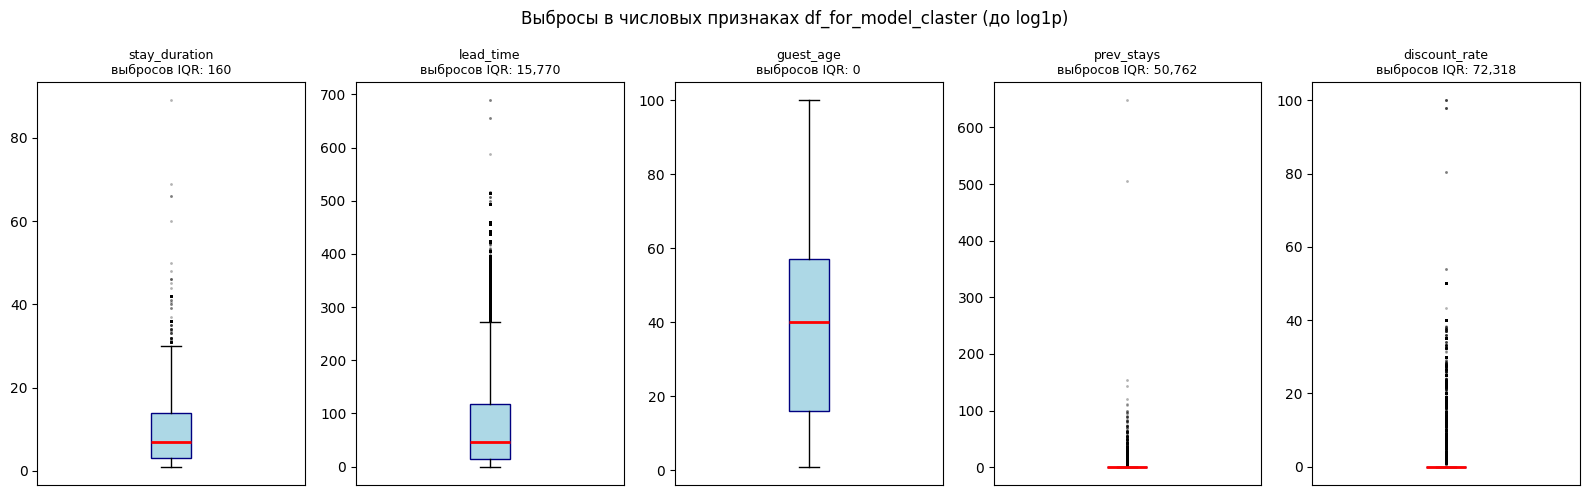

Описательная статистика (до log1p):
       stay_duration  lead_time  guest_age  prev_stays  discount_rate
count      436492.00  436492.00   314986.0   311509.00      436492.00
mean            8.41      78.39       38.7        1.52           2.06
std             6.02      83.67       22.2        2.61           5.46
min             1.00       0.00        1.0        1.00           0.00
25%             3.00      15.00       16.0        1.00           0.00
50%             7.00      47.00       40.0        1.00           0.00
75%            14.00     118.00       57.0        1.00           0.00
max            89.00     689.00      100.0      648.00         100.00


In [40]:
num_cols_vis = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate']

fig, axes = plt.subplots(1, len(num_cols_vis), figsize=(16, 5))
for i, col in enumerate(num_cols_vis):
    data = df_for_model_claster[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', alpha=0.3, markersize=2))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    axes[i].set_title(f'{col}\nвыбросов IQR: {n_outliers:,}', fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Выбросы в числовых признаках df_for_model_claster (до log1p)', fontsize=12)
plt.tight_layout()
plt.show()

print("Описательная статистика (до log1p):")
print(df_for_model_claster[num_cols_vis].describe().round(2))

## 10. Обработка пропусков и log1p-трансформация

### Почему нужна log1p-трансформация

`prev_stays` (max=648, p99=24) и `lead_time` (max=689, p95=255) имеют экстремальный правый хвост.
При обычном `StandardScaler` это искажает масштаб: большинство гостей получают значения вблизи нуля, а выбросы уходят на ~100 сигм — KMeans начинает игнорировать остальные признаки.

**Решение:** `log1p` сжимает хвост, сохраняя монотонность и ноль (`log1p(0)=0`).

**Порядок:** заполнение пропусков → `log1p` → `StandardScaler` (следующий шаг).

**Примечание по `prev_stays`:** фактически это накопленная активность по CRM (включает визиты до 2019).
Для 90.5% гостей совпадает с реальным числом заездов в датасете. Минимальное значение = 1;
`NaN` → 0 (гость не найден в CRM, интерпретируем как первичный).

Пропуски после заполнения:
guest_age     0
prev_stays    0
gender        0
dtype: int64


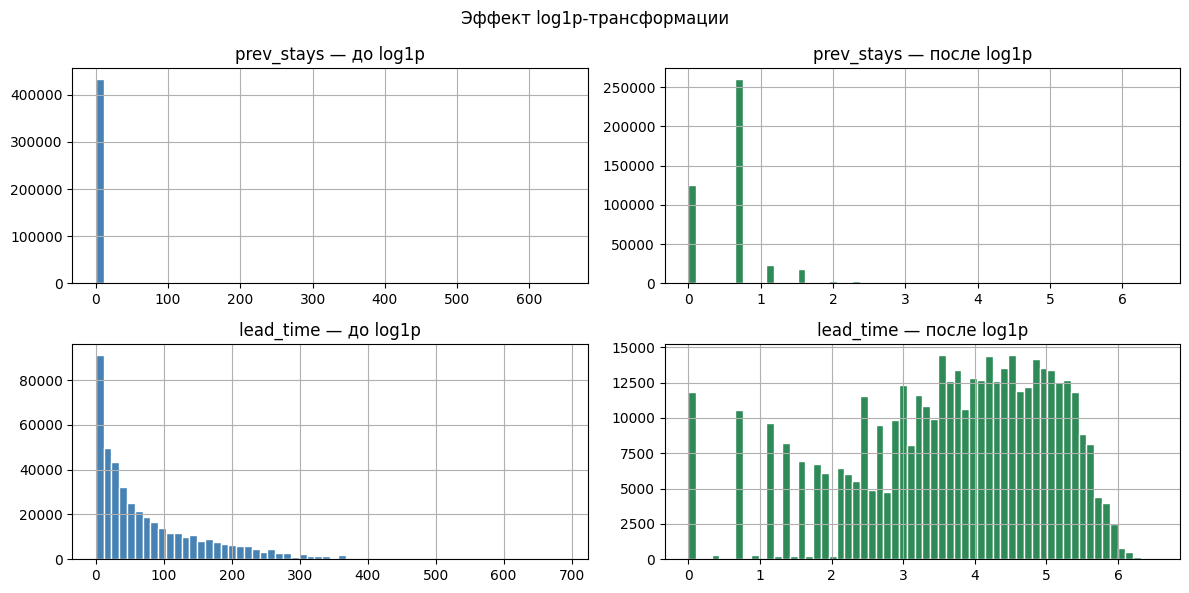


Статистика после log1p:
       prev_stays   lead_time
count  436492.000  436492.000
mean        0.587       3.652
std         0.475       1.418
min         0.000       0.000
25%         0.000       2.773
50%         0.693       3.871
75%         0.693       4.779
max         6.475       6.537


In [41]:
# --- Шаг 1: Заполнение пропусков ---
df_for_model_claster['guest_age'] = df_for_model_claster['guest_age'].fillna(
    df_for_model_claster['guest_age'].median()
)
# prev_stays NaN = нет данных в CRM → первичный гость (0 предыдущих визитов)
df_for_model_claster['prev_stays'] = df_for_model_claster['prev_stays'].fillna(0)
df_for_model_claster['gender']     = df_for_model_claster['gender'].fillna('unknown')

print("Пропуски после заполнения:")
print(df_for_model_claster[['guest_age', 'prev_stays', 'gender']].isna().sum())

# --- Шаг 2: Log1p для признаков с экстремальным правым хвостом ---
log_cols = ['prev_stays', 'lead_time']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, col in enumerate(log_cols):
    df_for_model_claster[col].hist(bins=60, ax=axes[i][0], color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{col} — до log1p')
    np.log1p(df_for_model_claster[col]).hist(bins=60, ax=axes[i][1], color='seagreen', edgecolor='white')
    axes[i][1].set_title(f'{col} — после log1p')
plt.suptitle('Эффект log1p-трансформации', fontsize=12)
plt.tight_layout()
plt.show()

for col in log_cols:
    df_for_model_claster[col] = np.log1p(df_for_model_claster[col])

print("\nСтатистика после log1p:")
print(df_for_model_claster[log_cols].describe().round(3))

## 11. Итоговый датасет — готово к кластеризации

In [42]:
# Финальный список признаков для матрицы X
X_num = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos']
X_cat = ['tariff_group', 'room_group', 'gender']
X_bin = ['has_children', 'is_weekend_in']
X_cols = X_num + X_cat + X_bin

print(f"df_for_model_claster: {df_for_model_claster.shape[0]:,} гостей × {df_for_model_claster.shape[1]} колонок")
print(f"Признаков для кластеризации (X): {len(X_cols)}")
print(f"  Числовые    ({len(X_num)}): {X_num}")
print(f"  Категор.    ({len(X_cat)}): {X_cat}")
print(f"  Бинарные    ({len(X_bin)}): {X_bin}")
print(f"\nМетаданные (не в X): guest_id, n_stays")

# Таблица признаков
feature_info = [
    ('stay_duration',  'num', 'mean',        'Средняя длительность пребывания (ночей)'),
    ('lead_time',      'num', 'mean+log1p',  'Горизонт бронирования (дней до заезда)'),
    ('guest_age',      'num', 'first',       'Возраст гостя (импутация медианой)'),
    ('prev_stays',     'num', 'max+log1p',   'Накопленная активность по CRM (≈ число заездов)'),
    ('discount_rate',  'num', 'mean',        'Средний % скидки (ценовая чувствительность)'),
    ('month_sin',      'num', 'mean',        'Циклическая сезонность — sin(2π·m/12)'),
    ('month_cos',      'num', 'mean',        'Циклическая сезонность — cos(2π·m/12)'),
    ('tariff_group',   'cat', 'mode',        'Ценовой сегмент / канал продаж (8 кат.)'),
    ('room_group',     'cat', 'mode',        'Категория номера (5 кат.)'),
    ('gender',         'cat', 'first',       'Пол (импутация: unknown)'),
    ('has_children',   'bin', 'max',         'Приезжал с детьми хоть раз'),
    ('is_weekend_in',  'bin', 'mean',        'Доля заездов в пятницу/субботу'),
]
feat_df = pd.DataFrame(feature_info, columns=['Признак', 'Тип', 'Агрегация', 'Бизнес-смысл'])
print('\n' + feat_df.to_string(index=False))

print("\n\nПропуски в финальном датасете:")
miss = df_for_model_claster[X_cols].isna().sum()
print(miss[miss > 0] if miss.sum() > 0 else "  Пропусков нет")

df_for_model_claster: 436,492 гостей × 14 колонок
Признаков для кластеризации (X): 12
  Числовые    (7): ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos']
  Категор.    (3): ['tariff_group', 'room_group', 'gender']
  Бинарные    (2): ['has_children', 'is_weekend_in']

Метаданные (не в X): guest_id, n_stays

      Признак Тип  Агрегация                                    Бизнес-смысл
stay_duration num       mean         Средняя длительность пребывания (ночей)
    lead_time num mean+log1p          Горизонт бронирования (дней до заезда)
    guest_age num      first              Возраст гостя (импутация медианой)
   prev_stays num  max+log1p Накопленная активность по CRM (≈ число заездов)
discount_rate num       mean     Средний % скидки (ценовая чувствительность)
    month_sin num       mean           Циклическая сезонность — sin(2π·m/12)
    month_cos num       mean           Циклическая сезонность — cos(2π·m/12)
 tariff_group cat       

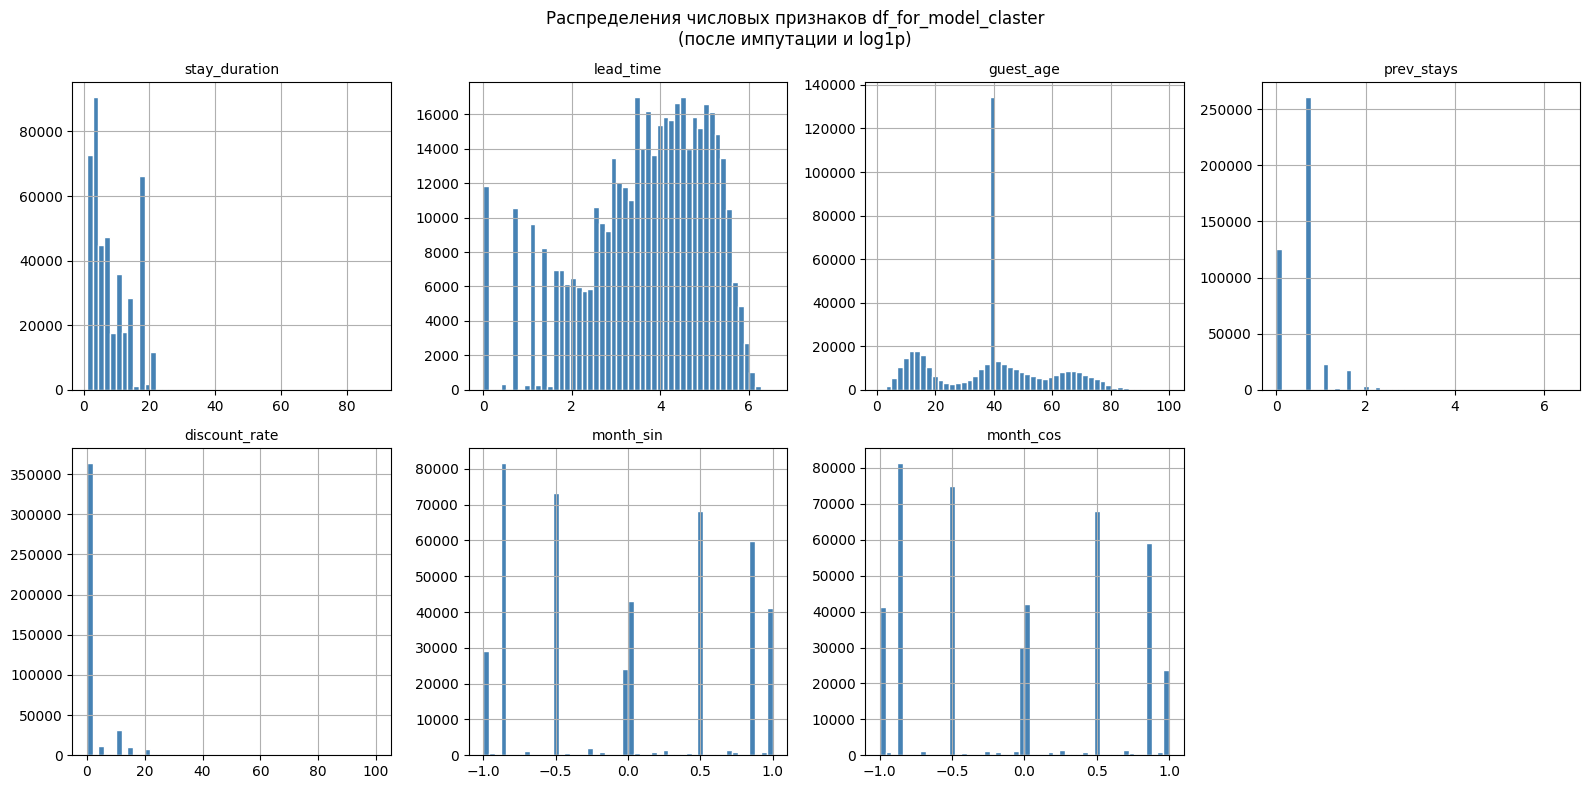

Готово! df_for_model_claster готов к кластеризации.
Следующий шаг: ColumnTransformer → StandardScaler (num) + OneHotEncoder (cat) → KMeans


In [43]:
# Распределения числовых признаков после всех трансформаций
num_after = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays',
             'discount_rate', 'month_sin', 'month_cos']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

for i, col in enumerate(num_after):
    df_for_model_claster[col].hist(bins=50, ax=axes_flat[i],
                                    color='steelblue', edgecolor='white')
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_xlabel('')

axes_flat[7].set_visible(False)

plt.suptitle(
    'Распределения числовых признаков df_for_model_claster\n(после импутации и log1p)',
    fontsize=12
)
plt.tight_layout()
plt.show()

print("Готово! df_for_model_claster готов к кластеризации.")
print("Следующий шаг: ColumnTransformer → StandardScaler (num) + OneHotEncoder (cat) → KMeans")

In [44]:
df_for_model_claster

,guest_id,stay_duration,lead_time,guest_age,prev_stays,discount_rate,month_sin,month_cos,gender,has_children,is_weekend_in,tariff_group,room_group,n_stays
0,15.0,8.0,2.564949,40.0,0.000000,10.0,-2.449294e-16,1.000000e+00,unknown,0,0.000000,новогодний/банкет,стандарт,1
1,36.0,3.0,2.639057,40.0,0.000000,0.0,8.660254e-01,5.000000e-01,unknown,0,1.000000,ультра/all-incl,стандарт,1
2,61.0,11.0,3.676301,73.0,1.609438,5.0,5.000000e-01,0.000000e+00,Женский,1,0.000000,other,стандарт,2
3,72.0,9.7,2.332144,36.0,1.945910,0.0,1.220085e-01,4.553418e-01,Мужской,0,0.333333,other,комфорт,3
4,73.0,9.3,3.332205,16.0,1.386294,0.0,5.773503e-01,1.480297e-16,Мужской,0,0.333333,событие/группы,стандарт,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436487,1882070.0,2.0,0.000000,35.0,0.693147,10.0,-8.660254e-01,5.000000e-01,Женский,0,0.000000,ультра/all-incl,стандарт,1
436488,1882071.0,2.0,0.000000,30.0,0.693147,10.0,-8.660254e-01,5.000000e-01,Женский,0,0.000000,ультра/all-incl,стандарт,1
436489,1882072.0,2.0,0.000000,55.0,0.693147,10.0,-8.660254e-01,5.000000e-01,Женский,0,0.000000,ультра/all-incl,стандарт,1
436490,1882081.0,2.0,0.000000,3.0,0.693147,10.0,-8.660254e-01,5.000000e-01,Мужской,0,0.000000,ультра/all-incl,стандарт,1


In [45]:
df_for_model_claster.room_group.unique()

<StringArray>
['стандарт', 'комфорт', 'люкс', 'апартаменты', 'other']
Length: 5, dtype: str

In [48]:
df_deduped.room_type.unique()

<StringArray>
[                       'СТД-СТАНДАРТ',                          'К -Комфорт',
                        'К+- Комфорт+',                  'ЛК2-ЛЮКС 2 КОМНАТЫ',
                  'ЛК3-ЛЮКС 3 КОМНАТЫ',                   'АПАРТ-АПАРТАМЕНТЫ',
                   'К-VS - VS-Комфорт',                  'К+VS - VS-Комфорт+',
                 'СТДVS - VS-СТАНДАРТ',           'ЛК3VS - VS-ЛЮКС 3 КОМНАТЫ',
           'ЛК2VS - VS-ЛЮКС 2 КОМНАТЫ', 'СТД 2 - СТД2-СТАНДАРТ(2-222, 2-227)',
                         'Брлн-Берлин',               'АПVS - VS-АПАРТАМЕНТЫ',
        'МРСК - Морская прохлада (К+)',                     'СЛУЖБ-СЛУЖЕБНЫЙ',
             'КфМрс - Комфорт Морской',                          'СТДКОМФОРТ',
                                'ЛЮКС',         'АП2К - АПАРТ 2 -Х КОМНАТНЫЙ',
              'АП+3К - 3 -Х КОМНАТНЫЙ',     'АП+ - АПАРТ ПЛЮС 1-НО КОМНАТНЫЙ',
       'АП+2К - АПАРТ+ 2 -Х КОМНАТНЫЙ',          'АП3К - АПАРТ 3-Х КОМНАТНЫЙ']
Length: 24, dtype: str